# 🎯 MATLAB-Style PID Tuning

Demonstration of two PID optimization modes:
- `mode="step_response"` — for step signals
- `mode="tracking"` — for trajectory tracking

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from pathlib import Path

from tensoraerospace.agent.pid import PID, MATLABTuneResult, StateSpaceNotAvailable
from tensoraerospace.utils import generate_time_period, convert_tp_to_sec_tp
from tensoraerospace.signals.standard import unit_step, sinusoid_vertical_shift
from tensoraerospace.benchmark.function import overshoot, settling_time, static_error

plt.rcParams['figure.figsize'] = [12, 5]
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True

print("✅ Libraries loaded")

✅ Библиотеки загружены


## 📊 Simulation Parameters

In [ ]:
dt = 0.1
tn = 50.0
step_amplitude = 1.0
step_time_idx = 100*dt  # now in seconds (was index)

tp = generate_time_period(tn=tn, dt=dt)
tps = convert_tp_to_sec_tp(tp, dt=dt)
number_time_steps = len(tp)

reference_signals = np.reshape(
    unit_step(degree=step_amplitude, tp=tp, time_step=step_time_idx, output_rad=True), 
    [1, -1]
)

print(f"📊 Parameters: tn={tn}s, dt={dt}s, steps={number_time_steps}")

## 🛫 Creating the B747 Environment

In [ ]:
env = gym.make(
    'LinearLongitudinalB747-v0',
    number_time_steps=number_time_steps,
    use_reward=False,
    initial_state=[[0], [0], [0], [0]],
    reference_signal=reference_signals,
    state_space=["u", "w", "q", "theta"],
    output_space=["u", "w", "q", "theta"],
    tracking_states=["theta"],
    dt=dt
)

print(f"✅ Environment created: {env.unwrapped.model.A.shape}")

## 🎯 PID Optimization (mode="step_response")

In [4]:
pid = PID(env=env, dt=dt)

result = pid.tune_matlab_style(
    track_state_idx=3,
    target_settling_time=15.0,
    target_overshoot=10.0,
    n_iterations=50,
    verbose=True,
    mode="step_response"
)

print(f"\n📊 Result: {result}")


📊 MATLAB-Style PID Optimization (Step Response)
------------------------------------------------------------
   System dimension: 4 states
   Matrices: A=(4, 4), B=(4, 1), C=(4, 4), D=(4, 1)
   Simulation steps: 501, dt: 0.1s
   Mode: Step Response
   Target settling time: 15.0s
   Target overshoot: 10.0%
   DC Gain: -0.9098

   🔄 Running optimization (50 iterations)...


   Optimization:   0%|          | 0/50 [00:00<?]

/home/mr8bit/Projects/TensorAeroSpace/.venv/lib/python3.11/site-packages/gymnasium/utils/passive_env_checker.py:159: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
/home/mr8bit/Projects/TensorAeroSpace/.venv/lib/python3.11/site-packages/gymnasium/utils/passive_env_checker.py:159: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")



   ✅ Optimization completed!
   Kp=-20.7356, Ki=-5.5148, Kd=-5.7358
   [Primary step] Settling time: 10.30s
   [Primary step] Overshoot: 4.88%
   [Primary step] Static error: -0.0016
   [Secondary sine] RMSE: 0.0571

📊 Результат: MATLABTuneResult(Kp=-20.7356, Ki=-5.5148, Kd=-5.7358, settling_time=10.30s, overshoot=4.88%)


## 📈 Testing Step Response PID on a Step Input

In [ ]:
env_step1 = gym.make('LinearLongitudinalB747-v0', number_time_steps=number_time_steps, use_reward=False,
    initial_state=[[0], [0], [0], [0]], reference_signal=reference_signals,
    state_space=["u", "w", "q", "theta"], output_space=["u", "w", "q", "theta"],
    tracking_states=["theta"], dt=dt)

env_step1.reset()
pid.reset()

xt_step1 = np.array([[0.0], [0.0], [0.0], [0.0]])
control_step1_history = []
reference_step_deg = np.rad2deg(reference_signals[0])

for step in range(number_time_steps - 2):
    setpoint = reference_step_deg[step]
    measurement = np.asarray(xt_step1).reshape(-1)[3]
    control = pid.select_action(setpoint, measurement)
    control_step1_history.append(control)
    xt_step1, _, done, _, _ = env_step1.step(np.array([control]))
    if done: break

theta_step1_response = env_step1.unwrapped.model.get_state('theta', to_deg=True)
print(f"✅ Step Response PID: {len(theta_step1_response)} steps")

## 🌊 Creating a Sinusoidal Signal

In [ ]:
sin_amplitude = 3.0
sin_frequency = 0.005/dt  # was per-index; real Hz = 0.005/dt = 0.05
sin_offset = 2.0

tp_array = np.array(tp)
reference_sin_deg = sinusoid_vertical_shift(tp_array, frequency=sin_frequency, 
    amplitude=sin_amplitude, vertical_shift=sin_offset)

reference_sin_rad = np.deg2rad(reference_sin_deg)
reference_sin_signals = np.reshape(reference_sin_rad, [1, -1])

print(f"📊 Sine: A={sin_amplitude}°, f={sin_frequency}Hz, offset={sin_offset}°")

## 🌊 PID Optimization (mode="tracking")

In [7]:
env_tracking = gym.make('LinearLongitudinalB747-v0', number_time_steps=number_time_steps, use_reward=False,
    initial_state=[[0], [0], [0], [0]], reference_signal=reference_sin_signals,
    state_space=["u", "w", "q", "theta"], output_space=["u", "w", "q", "theta"],
    tracking_states=["theta"], dt=dt)

pid_tracking = PID(env=env_tracking, dt=dt)

print(f"📊 Step Response PID: Kp={pid.kp:.4f}, Ki={pid.ki:.4f}, Kd={pid.kd:.4f}\n")

result_tracking = pid_tracking.tune_matlab_style(
    track_state_idx=3, n_iterations=50, verbose=True, mode="tracking"
)

print(f"\n📊 Comparison:")
print(f"   Step Response: Kp={pid.kp:.4f}, Ki={pid.ki:.4f}, Kd={pid.kd:.4f}")
print(f"   Tracking:      Kp={pid_tracking.kp:.4f}, Ki={pid_tracking.ki:.4f}, Kd={pid_tracking.kd:.4f}")

📊 Step Response PID: Kp=-20.7356, Ki=-5.5148, Kd=-5.7358


🌊 MATLAB-Style PID Optimization (Signal Tracking)
------------------------------------------------------------
   System dimension: 4 states
   Matrices: A=(4, 4), B=(4, 1), C=(4, 4), D=(4, 1)
   Simulation steps: 501, dt: 0.1s
   Mode: Signal Tracking
   Objective: Minimize RMSE and phase lag
   DC Gain: -0.9098

   🔄 Running optimization (50 iterations)...


   Optimization:   0%|          | 0/50 [00:00<?]


   ✅ Optimization completed!
   Kp=-17.2677, Ki=-2.0015, Kd=-14.2924
   [Primary tracking] RMSE: 1.8332
   [Primary tracking] IAE: 82.2531
   [Secondary step] Overshoot: 4.79%
   [Secondary step] Settling time: 12.40s

📊 Сравнение:
   Step Response: Kp=-20.7356, Ki=-5.5148, Kd=-5.7358
   Tracking:      Kp=-17.2677, Ki=-2.0015, Kd=-14.2924


## 📈 Testing Tracking PID on a Step Input

In [ ]:
env_step2 = gym.make('LinearLongitudinalB747-v0', number_time_steps=number_time_steps, use_reward=False,
    initial_state=[[0], [0], [0], [0]], reference_signal=reference_signals,
    state_space=["u", "w", "q", "theta"], output_space=["u", "w", "q", "theta"],
    tracking_states=["theta"], dt=dt)

env_step2.reset()
pid_tracking.reset()

xt_step2 = np.array([[0.0], [0.0], [0.0], [0.0]])
control_step2_history = []

for step in range(number_time_steps - 2):
    setpoint = reference_step_deg[step]
    measurement = np.asarray(xt_step2).reshape(-1)[3]
    control = pid_tracking.select_action(setpoint, measurement)
    control_step2_history.append(control)
    xt_step2, _, done, _, _ = env_step2.step(np.array([control]))
    if done: break

theta_step2_response = env_step2.unwrapped.model.get_state('theta', to_deg=True)
print(f"✅ Tracking PID: {len(theta_step2_response)} steps")

## 📊 Comparison on STEP Input

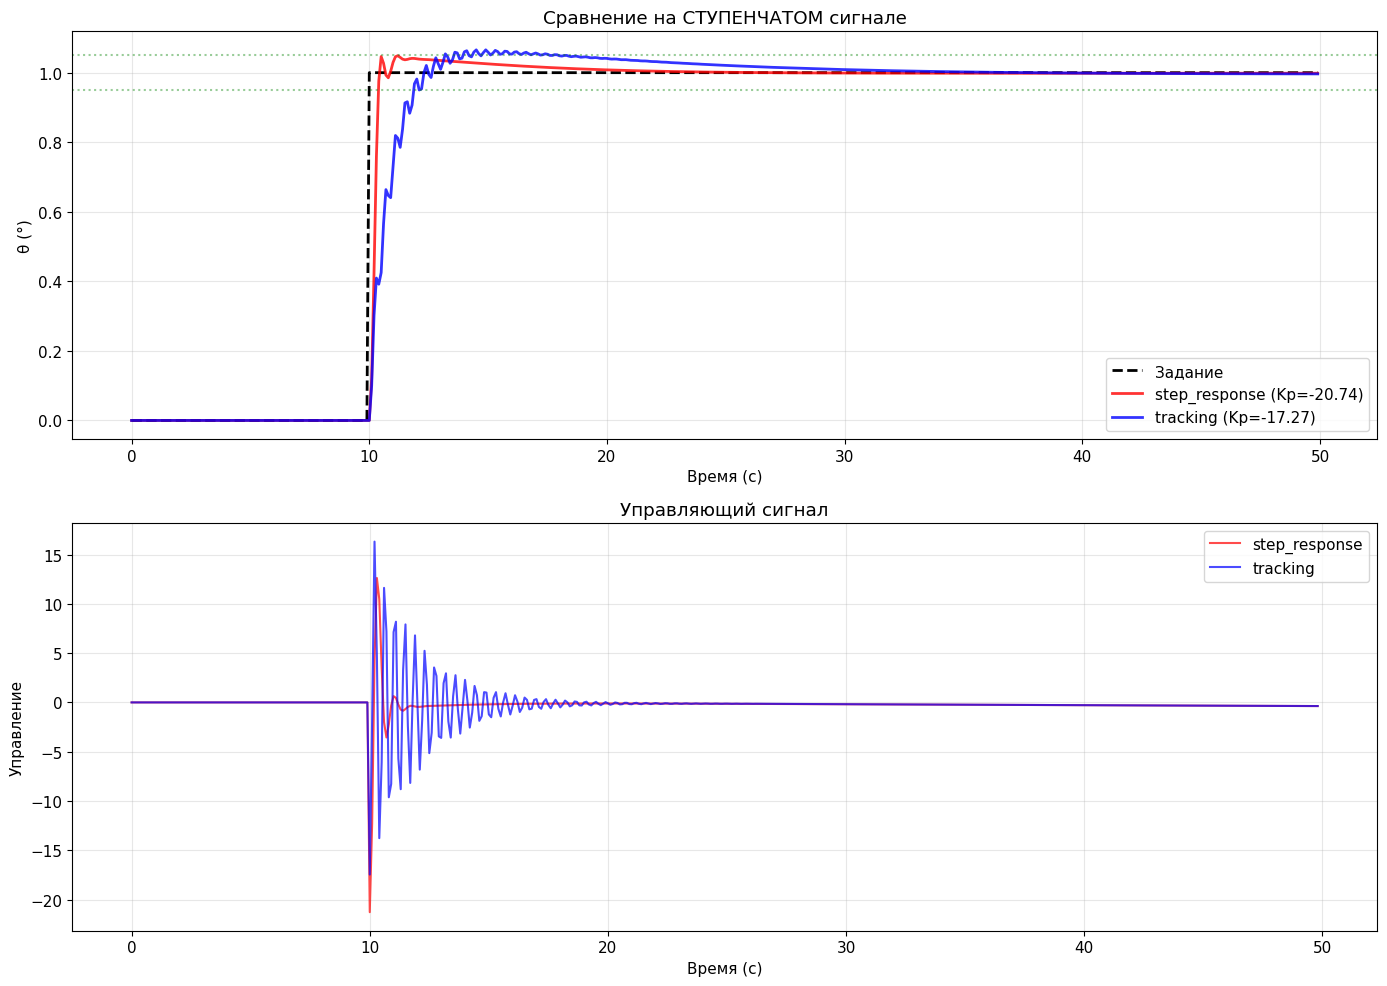

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

N_step = min(len(theta_step1_response), len(theta_step2_response), len(reference_step_deg))

ax1 = axes[0]
ax1.plot(tps[:N_step], reference_step_deg[:N_step], 'k--', linewidth=2, label='Reference')
ax1.plot(tps[:N_step], theta_step1_response[:N_step], 'r-', linewidth=2, alpha=0.8,
         label=f'step_response (Kp={pid.kp:.2f})')
ax1.plot(tps[:N_step], theta_step2_response[:N_step], 'b-', linewidth=2, alpha=0.8,
         label=f'tracking (Kp={pid_tracking.kp:.2f})')
ax1.axhline(y=step_amplitude * 0.95, color='g', linestyle=':', alpha=0.4)
ax1.axhline(y=step_amplitude * 1.05, color='g', linestyle=':', alpha=0.4)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('θ (°)')
ax1.set_title('Comparison on STEP signal')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(tps[:len(control_step1_history)], control_step1_history, 'r-', alpha=0.7, label='step_response')
ax2.plot(tps[:len(control_step2_history)], control_step2_history, 'b-', alpha=0.7, label='tracking')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Control')
ax2.set_title('Control signal')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 📈 Tests on SINUSOIDAL Input

In [ ]:
# Step Response PID on the sine wave
env_sin1 = gym.make('LinearLongitudinalB747-v0', number_time_steps=number_time_steps, use_reward=False,
    initial_state=[[0], [0], [0], [0]], reference_signal=reference_sin_signals,
    state_space=["u", "w", "q", "theta"], output_space=["u", "w", "q", "theta"],
    tracking_states=["theta"], dt=dt)

env_sin1.reset()
pid.reset()
xt_sin1 = np.array([[0.0], [0.0], [0.0], [0.0]])

for step in range(number_time_steps - 2):
    setpoint = reference_sin_deg[step]
    measurement = np.asarray(xt_sin1).reshape(-1)[3]
    control = pid.select_action(setpoint, measurement)
    xt_sin1, _, done, _, _ = env_sin1.step(np.array([control]))
    if done: break

theta_sin1_response = env_sin1.unwrapped.model.get_state('theta', to_deg=True)

# Tracking PID on the sine wave
env_sin2 = gym.make('LinearLongitudinalB747-v0', number_time_steps=number_time_steps, use_reward=False,
    initial_state=[[0], [0], [0], [0]], reference_signal=reference_sin_signals,
    state_space=["u", "w", "q", "theta"], output_space=["u", "w", "q", "theta"],
    tracking_states=["theta"], dt=dt)

env_sin2.reset()
pid_tracking.reset()
xt_sin2 = np.array([[0.0], [0.0], [0.0], [0.0]])

for step in range(number_time_steps - 2):
    setpoint = reference_sin_deg[step]
    measurement = np.asarray(xt_sin2).reshape(-1)[3]
    control = pid_tracking.select_action(setpoint, measurement)
    xt_sin2, _, done, _, _ = env_sin2.step(np.array([control]))
    if done: break

theta_sin2_response = env_sin2.unwrapped.model.get_state('theta', to_deg=True)

print(f"✅ Sine-wave tests finished")

## 📊 Comparison on SINUSOIDAL Input

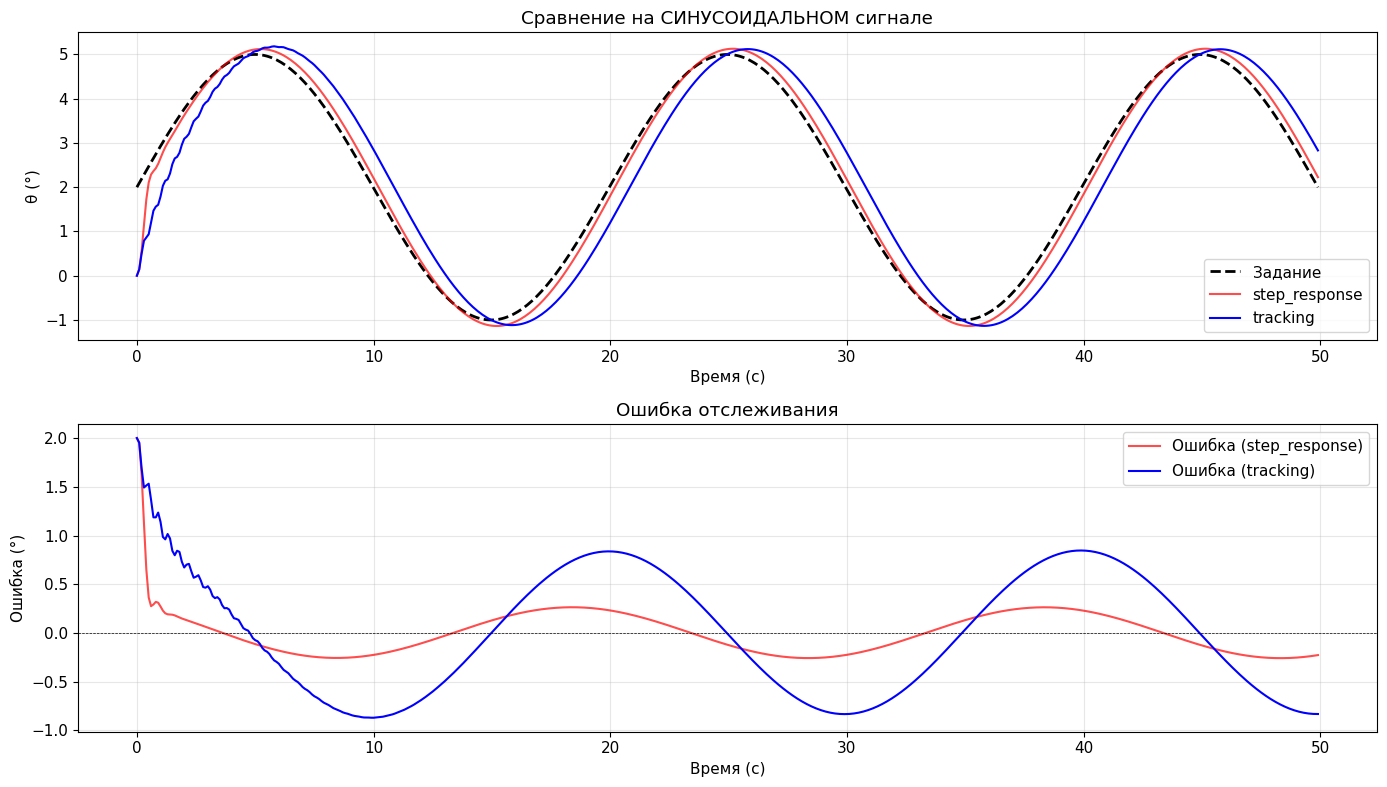

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

N_sin = min(len(theta_sin1_response), len(theta_sin2_response), len(reference_sin_deg))

ax1 = axes[0]
ax1.plot(tps[:N_sin], reference_sin_deg[:N_sin], 'k--', linewidth=2, label='Reference')
ax1.plot(tps[:N_sin], theta_sin1_response[:N_sin], 'r-', linewidth=1.5, alpha=0.7, label='step_response')
ax1.plot(tps[:N_sin], theta_sin2_response[:N_sin], 'b-', linewidth=1.5, label='tracking')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('θ (°)')
ax1.set_title('Comparison on SINE signal')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
error_sin1 = reference_sin_deg[:N_sin] - theta_sin1_response[:N_sin]
error_sin2 = reference_sin_deg[:N_sin] - theta_sin2_response[:N_sin]
ax2.plot(tps[:N_sin], error_sin1, 'r-', alpha=0.7, label='Error (step_response)')
ax2.plot(tps[:N_sin], error_sin2, 'b-', label='Error (tracking)')
ax2.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Error (°)')
ax2.set_title('Tracking error')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 📋 Final Benchmarking

In [17]:
# Metrics on the step
os_step1 = abs(overshoot(reference_step_deg[:N_step], theta_step1_response[:N_step]))
st_step1 = settling_time(reference_step_deg[:N_step], theta_step1_response[:N_step]) * dt
se_step1 = abs(static_error(reference_step_deg[:N_step], theta_step1_response[:N_step]))

os_step2 = abs(overshoot(reference_step_deg[:N_step], theta_step2_response[:N_step]))
st_step2 = settling_time(reference_step_deg[:N_step], theta_step2_response[:N_step]) * dt
se_step2 = abs(static_error(reference_step_deg[:N_step], theta_step2_response[:N_step]))

# Metrics on the sine wave
rmse_sin1 = np.sqrt(np.mean(error_sin1**2))
rmse_sin2 = np.sqrt(np.mean(error_sin2**2))
max_err_sin1 = np.max(np.abs(error_sin1))
max_err_sin2 = np.max(np.abs(error_sin2))

print("=" * 90)
print("📊 FINAL BENCHMARK")
print("=" * 90)

print("\n🔹 PID parameters:")
print(f"   step_response: Kp={pid.kp:.4f}, Ki={pid.ki:.4f}, Kd={pid.kd:.4f}")
print(f"   tracking:      Kp={pid_tracking.kp:.4f}, Ki={pid_tracking.ki:.4f}, Kd={pid_tracking.kd:.4f}")

print("\n" + "-" * 90)
print(f"{'Signal':<15} {'Metric':<25} {'step_response':<15} {'tracking':<15} {'Best'}")
print("-" * 90)
print(f"{'STEP':<15} {'Overshoot (%)':<25} {os_step1:<15.2f} {os_step2:<15.2f} {'🏆 step' if os_step1 < os_step2 else '🏆 track'}")
print(f"{'':<15} {'Settling time (s)':<25} {st_step1:<15.2f} {st_step2:<15.2f} {'🏆 step' if st_step1 < st_step2 else '🏆 track'}")
print(f"{'':<15} {'Static error (°)':<25} {se_step1:<15.4f} {se_step2:<15.4f} {'🏆 step' if se_step1 < se_step2 else '🏆 track'}")
print("-" * 90)
print(f"{'SINE':<15} {'RMSE (°)':<25} {rmse_sin1:<15.4f} {rmse_sin2:<15.4f} {'🏆 step' if rmse_sin1 < rmse_sin2 else '🏆 track'}")
print(f"{'':<15} {'Max error (°)':<25} {max_err_sin1:<15.4f} {max_err_sin2:<15.4f} {'🏆 step' if max_err_sin1 < max_err_sin2 else '🏆 track'}")
print("-" * 90)

print("\n💡 CONCLUSION:")
print("   • mode='step_response' is better for STEP signals")
print("   • mode='tracking' is better for SINE signals")

📊 ИТОГОВЫЙ БЕНЧМАРКИНГ

🔹 Параметры PID:
   step_response: Kp=-20.7356, Ki=-5.5148, Kd=-5.7358
   tracking:      Kp=-17.2677, Ki=-2.0015, Kd=-14.2924

------------------------------------------------------------------------------------------
Сигнал          Метрика                   step_response   tracking        Лучший
------------------------------------------------------------------------------------------
СТУПЕНЬКА       Overshoot (%)             4.88            6.56            🏆 step
                Settling time (с)         10.40           18.00           🏆 step
                Static error (°)          0.0016          0.0032          🏆 step
------------------------------------------------------------------------------------------
СИНУСОИДА       RMSE (°)                  0.2420          0.6304          🏆 step
                Max error (°)             2.0000          2.0000          🏆 track
-----------------------------------------------------------------------------------------